In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.cluster import DBSCAN

In [108]:
def wrap_pi(a):
    return (a + np.pi) % (2*np.pi) - np.pi

def analyze_endpoints_file(csv_path, eps=1, min_samples=1):
    df = pd.read_csv(csv_path)

    df = df[df["d_final"] <= 19].copy()

    df["force_norm"] = np.sqrt(df["F_d"]**2 + df["F_theta1"]**2 + df["F_theta2"]**2)

    X = np.column_stack([
        df["d_final"].values,
        np.cos(df["theta1_final"].values),
        np.sin(df["theta1_final"].values),
        np.cos(df["theta2_final"].values),
        np.sin(df["theta2_final"].values),
    ])

    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)
    df["cluster"] = labels

    return df

def classify_fixed_and_loops(df, eps_loop=1.0, min_samples_loop=1, force_tol=1e-3):
    df = df.copy()

    df["force_norm"] = np.sqrt(df["F_d"]**2 + df["F_theta1"]**2 + df["F_theta2"]**2)

    fixed = df[df["force_norm"] < force_tol].copy()
    fixed["attractor_type"] = "fixed"
    moving = df[df["force_norm"] >= force_tol].copy()
    moving["attractor_type"] = "loop_or_moving"

    X_fixed = np.column_stack([
        fixed["d_final"].values,
        np.cos(fixed["theta1_final"].values),
        np.sin(fixed["theta1_final"].values),
        np.cos(fixed["theta2_final"].values),
        np.sin(fixed["theta2_final"].values),
    ])
    
    if len(fixed) > 0:
        fixed_labels = DBSCAN(eps=0.12, min_samples=1).fit_predict(X_fixed)
        fixed["attractor_id"] = ["Fixed_" + str(i) for i in fixed_labels]

    X_loop = np.column_stack([
        moving["d_final"].values,
        np.cos(moving["theta1_final"].values),
        np.sin(moving["theta1_final"].values),
        np.cos(moving["theta2_final"].values),
        np.sin(moving["theta2_final"].values),
    ])

    if len(moving) > 0:
        loop_labels = DBSCAN(eps=eps_loop, min_samples=min_samples_loop).fit_predict(X_loop)
        moving["attractor_id"] = ["Moving_" + str(i) for i in loop_labels]

    return pd.concat([fixed, moving], ignore_index=True)

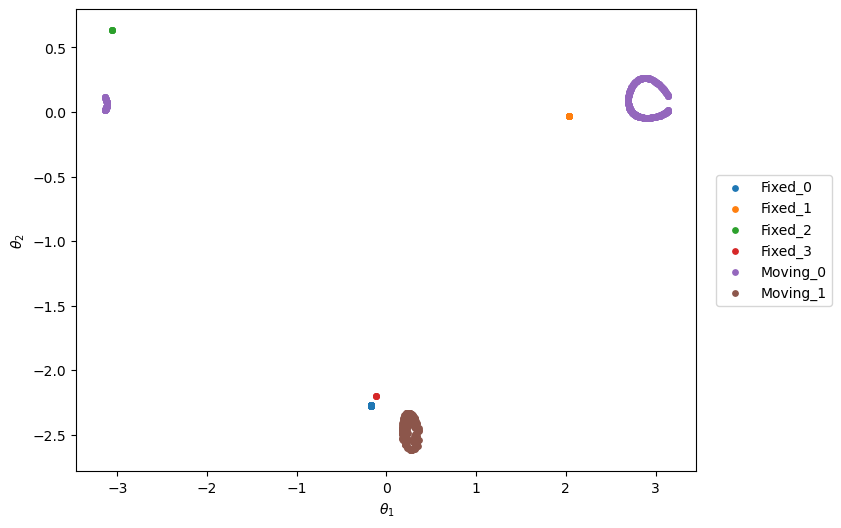

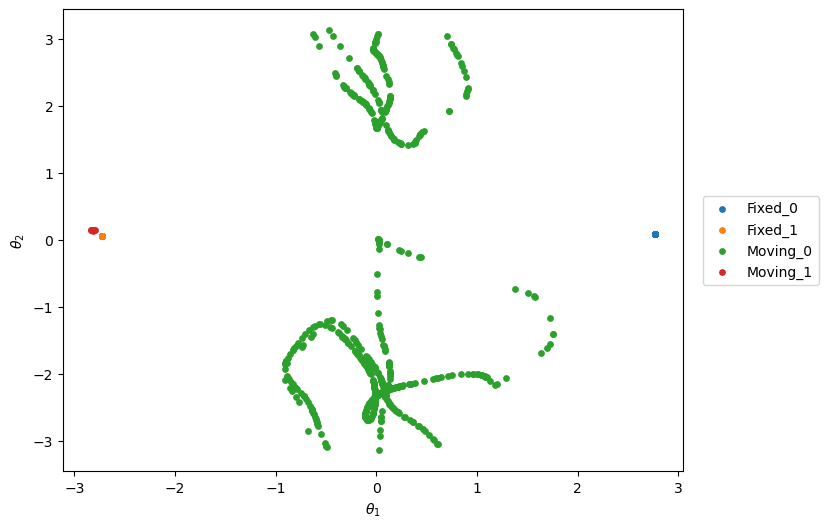

In [117]:
exp_id =2
#result_first = analyze_endpoints_file(f"../Results/Exp_{exp_id}_fight1/Endpoints_exp{exp_id}_fight1_first_half.csv")
#result_last = analyze_endpoints_file(f"../Results/Exp_{exp_id}_fight1/Endpoints_exp{exp_id}_fight1_last_half.csv")

## exp 2

result_first = analyze_endpoints_file(f"../Results/Exp_2_fight1/endpoints_forces_real.csv")
result_last = analyze_endpoints_file(f"../Results/Exp_2_fight1/endpoints_forces_real_last50%.csv")

classified_first = classify_fixed_and_loops(result_first,eps_loop=1.0,min_samples_loop=1,force_tol=1e-3)
classified_last = classify_fixed_and_loops(result_last,eps_loop=1.0,min_samples_loop=1,force_tol=1e-3)
classified_first.to_csv(f'../Results/Exp_{exp_id}_fight1/Classified_first.csv')
classified_last.to_csv(f'../Results/Exp_{exp_id}_fight1/Classified_last.csv')

plt.figure(figsize=(8,6))

for name, g in classified_first.groupby("attractor_id"):
    plt.scatter(g["theta1_final"], g["theta2_final"], s=15, label=name)

plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.savefig(f'../Results/Exp_{exp_id}_fight1/Clustered_endpoints_first.png',bbox_inches="tight")
plt.show()

plt.figure(figsize=(8,6))

for name, g in classified_last.groupby("attractor_id"):
    plt.scatter(g["theta1_final"], g["theta2_final"], s=15, label=name)

plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.savefig(f'../Results/Exp_{exp_id}_fight1/Clustered_endpoints_last.png',bbox_inches="tight")
plt.show()

In [77]:
print(classified_first)

       d0   theta10   theta20   d_final  theta1_final  theta2_final       F_d  \
0     1.0 -3.141593 -3.141593  2.520052      2.767537      0.092265 -0.000639   
1     1.0 -3.141593 -1.884956  2.519840      2.767642      0.092265  0.000636   
2     1.0 -3.141593 -1.256637  2.519840      2.767644      0.092263  0.000671   
3     1.0 -3.141593 -0.628319  2.519850      2.767605      0.092273  0.000119   
4     1.0 -3.141593  0.000000  2.519999      2.767579      0.092254 -0.000092   
...   ...       ...       ...       ...           ...           ...       ...   
1495  8.0  1.256637 -1.884956  3.366515     -0.003897      1.695568 -6.553518   
1496  8.0  1.256637  1.256637  6.181411     -0.015089     -2.299682  0.783335   
1497  8.0  2.513274 -3.141593  2.748836      1.006724     -2.003159  3.199092   
1498  8.0  2.513274 -2.513274  3.369112     -0.026181      2.827498  5.194410   
1499  8.0  2.513274  1.256637  7.769491     -2.796185      0.145601 -0.201441   

      F_theta1  F_theta2  f

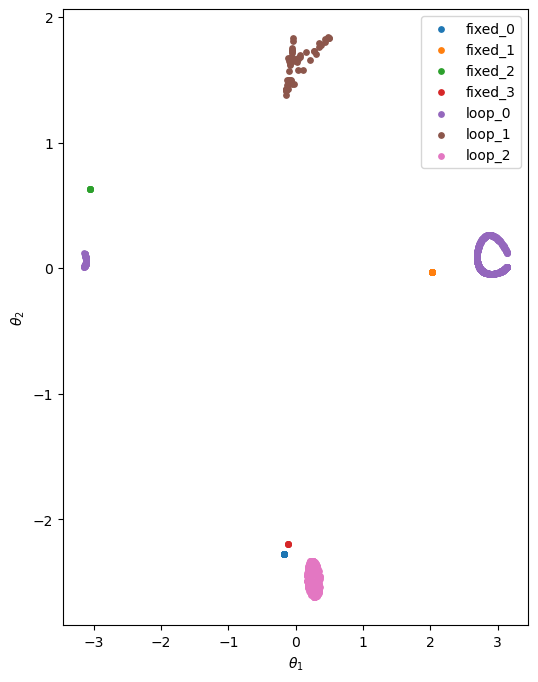

In [69]:
classified_last = classify_fixed_and_loops(
    result_last,
    eps_loop=1.0,
    min_samples_loop=1,
    force_tol=1e-3
)

plt.figure(figsize=(6,8))

for name, g in classified_last.groupby("attractor_id"):
    plt.scatter(g["theta1_final"], g["theta2_final"], s=15, label=name)

plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.legend()
plt.show()